# Food Delivery Time Analysis & Prediction

**Project Type:** Beginner-to-Intermediate Data Science Portfolio Project  
**Domain:** Food Delivery / Logistics Analytics  
**Main Focus:** Data Cleaning, EDA, Business Insights  
**Small ML Part:** Predict delivery time in minutes

## Dataset Used
Kaggle Dataset: **Food Delivery Dataset**  
Dataset Link: https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset

## Business Problem
Food delivery platforms need to understand what factors increase or decrease delivery time.  
This project analyzes delivery data and builds a simple prediction model to estimate delivery time using order, traffic, weather, city, and delivery partner features.

## 1. Import Required Libraries

In [52]:
# Core libraries
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# Light, professional chart style
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 2. Load Dataset

In [53]:
df = pd.read_csv('train.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (45593, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


## 3. Dataset Overview

In [54]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())

display(df.head())
display(df.tail())

Rows: 45593
Columns: 20

Column Names:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26
45592,0x5fb2,RANCHIRES09DEL02,23,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10:00,17:15:00,conditions Fog,Medium,2,Snack,scooter,1,No,Metropolitian,(min) 36


In [55]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 


In [56]:
print("Numerical Summary:")
display(df.describe().T)

print("Categorical Summary:")
display(df.describe(include="object").T)

Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
Restaurant_latitude,45593.0,17.017729,8.185109,-30.905562,12.933284,18.546947,22.728163,30.914057
Restaurant_longitude,45593.0,70.231332,22.883647,-88.366217,73.170000,75.898497,78.044095,88.433452
Delivery_location_latitude,45593.0,17.465186,7.335122,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45593.0,70.845702,21.118812,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45593.0,1.023359,0.839065,0.000000,0.000000,1.000000,2.000000,3.000000


Categorical Summary:


,count,unique,top,freq
ID,45593,45593,0x4607,1
Delivery_person_ID,45593,1320,PUNERES01DEL01,67
Delivery_person_Age,45593,23,35,2262
Delivery_person_Ratings,45593,29,4.8,7148
Order_Date,45593,44,15-03-2022,1192
Time_Orderd,45593,177,NaN,1731
Time_Order_picked,45593,193,21:30:00,496
Weatherconditions,45593,7,conditions Fog,7654
Road_traffic_density,45593,5,Low,15477
Type_of_order,45593,4,Snack,11533


## 4. Data Cleaning

Real-world datasets often contain:
- Extra spaces in column names and values
- Missing values
- Wrong data types
- Text mixed with numbers
- Unnecessary ID columns

In [57]:
# Keep original copy
raw_df = df.copy()

# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Standardize string values
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"nan": np.nan, "NaN": np.nan, "NULL": np.nan, "": np.nan})

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']


In [58]:
# Rename common inconsistent column names for easier use
rename_map = {
    "Weatherconditions": "Weather_conditions",
    "Weather_conditions": "Weather_conditions",
    "Time_taken(min)": "Time_taken_min",
    "Time_taken_(min)": "Time_taken_min",
    "Time_Orderd": "Time_Ordered"
}
df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

print(df.columns.tolist())

['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Ordered', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken_min']


In [59]:
def extract_number(value):
    """Extract numeric value from mixed text like '(min) 30' or '30 minutes'."""
    if pd.isna(value):
        return np.nan
    match = re.search(r"[-+]?\d*\.?\d+", str(value))
    return float(match.group()) if match else np.nan

# Convert target variable to numeric
if "Time_taken_min" in df.columns:
    df["Time_taken_min"] = df["Time_taken_min"].apply(extract_number)

# Clean weather column values if available
if "Weather_conditions" in df.columns:
    df["Weather_conditions"] = (
        df["Weather_conditions"]
        .astype(str)
        .str.replace("conditions ", "", regex=False)
        .str.strip()
        .replace({"nan": np.nan})
    )

# Convert possible numeric columns
possible_numeric_columns = [
    "Delivery_person_Age", "Delivery_person_Ratings",
    "Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude",
    "Vehicle_condition", "multiple_deliveries"
]

for col in possible_numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Ordered,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken_min
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0


### Missing Value Check

In [60]:
missing_summary = (
    df.isnull().sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing_Count"})
)
missing_summary["Missing_Percentage"] = round((missing_summary["Missing_Count"] / len(df)) * 100, 2)
missing_summary = missing_summary.sort_values(by="Missing_Count", ascending=False)

display(missing_summary[missing_summary["Missing_Count"] > 0])

,Column,Missing_Count,Missing_Percentage
3,Delivery_person_Ratings,1908,4.18
2,Delivery_person_Age,1854,4.07
9,Time_Ordered,1731,3.80
18,City,1200,2.63
16,multiple_deliveries,993,2.18
12,Road_traffic_density,601,1.32
17,Festival,228,0.50


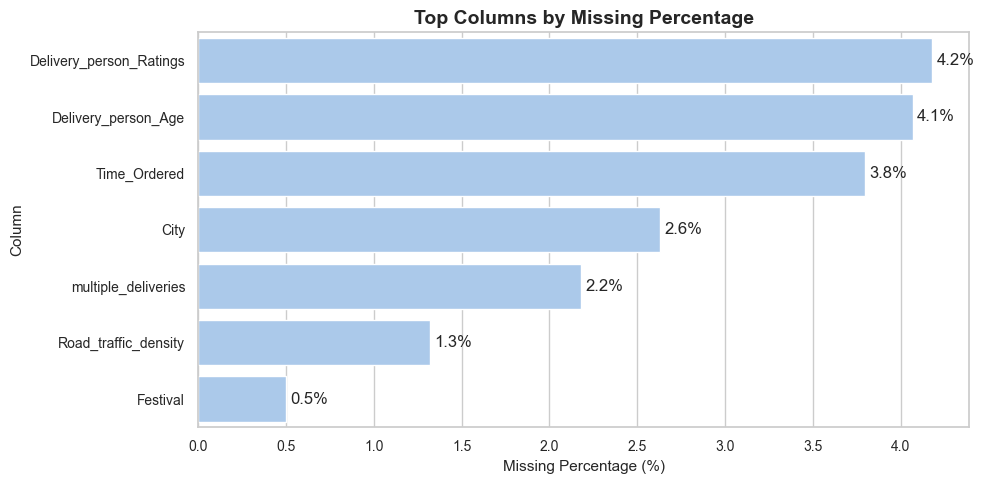

In [61]:
# Visualize top missing values
missing_plot = missing_summary[missing_summary["Missing_Count"] > 0].head(10)

if len(missing_plot) > 0:
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=missing_plot, x="Missing_Percentage", y="Column")
    plt.title("Top Columns by Missing Percentage", weight="bold")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Column")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

### Duplicate Check

In [62]:
duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)

Duplicate Rows: 0


### Missing Value Handling

For EDA:
- Numerical columns are filled using median.
- Categorical columns are filled using mode.

In [63]:
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_clean.select_dtypes(exclude=np.number).columns.tolist()

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    if df_clean[col].mode().empty:
        df_clean[col] = df_clean[col].fillna("Unknown")
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after handling:", df_clean.isnull().sum().sum())
df_clean.head()

Missing values after handling: 0


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Ordered,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken_min
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0


## 5. Feature Engineering

We will create useful features for better analysis and prediction:
- Delivery distance using latitude and longitude
- Order day/month if date is available
- Time gap between order time and pickup time if time columns are available

In [64]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance between two latitude/longitude points in kilometers."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

required_location_cols = [
    "Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude"
]

if all(col in df_clean.columns for col in required_location_cols):
    df_clean["Distance_km"] = haversine_distance(
        df_clean["Restaurant_latitude"],
        df_clean["Restaurant_longitude"],
        df_clean["Delivery_location_latitude"],
        df_clean["Delivery_location_longitude"]
    )

    # Remove unrealistic distance values for safer beginner-level analysis
    df_clean.loc[df_clean["Distance_km"] > 100, "Distance_km"] = np.nan
    df_clean["Distance_km"] = df_clean["Distance_km"].fillna(df_clean["Distance_km"].median())
else:
    print("Location columns not available. Distance feature skipped.")

# Date features
if "Order_Date" in df_clean.columns:
    df_clean["Order_Date"] = pd.to_datetime(df_clean["Order_Date"], errors="coerce")
    df_clean["Order_Day"] = df_clean["Order_Date"].dt.day
    df_clean["Order_Month"] = df_clean["Order_Date"].dt.month
    df_clean["Order_Weekday"] = df_clean["Order_Date"].dt.day_name()
    df_clean["Order_Weekday"] = df_clean["Order_Weekday"].fillna("Unknown")

df_clean.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Ordered,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken_min,Distance_km,Order_Day,Order_Month,Order_Weekday
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0,3.025149,19,3,Saturday
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0,20.183530,25,3,Friday
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0,1.552758,19,3,Saturday
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0,7.790401,5,4,Tuesday
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0,6.210138,26,3,Saturday


In [65]:
# Time difference between order and pickup, if columns are available
def time_to_minutes(value):
    if pd.isna(value):
        return np.nan
    try:
        value = str(value).strip()
        hour, minute = value.split(":")[:2]
        return int(hour) * 60 + int(minute)
    except Exception:
        return np.nan

if "Time_Ordered" in df_clean.columns and "Time_Order_picked" in df_clean.columns:
    order_minutes = df_clean["Time_Ordered"].apply(time_to_minutes)
    picked_minutes = df_clean["Time_Order_picked"].apply(time_to_minutes)
    df_clean["Order_to_Pickup_Min"] = picked_minutes - order_minutes

    # Handle cases where pickup happened after midnight
    df_clean.loc[df_clean["Order_to_Pickup_Min"] < 0, "Order_to_Pickup_Min"] += 24 * 60

    # Replace unrealistic values
    df_clean.loc[df_clean["Order_to_Pickup_Min"] > 180, "Order_to_Pickup_Min"] = np.nan
    df_clean["Order_to_Pickup_Min"] = df_clean["Order_to_Pickup_Min"].fillna(df_clean["Order_to_Pickup_Min"].median())

df_clean.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Ordered,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken_min,Distance_km,Order_Day,Order_Month,Order_Weekday,Order_to_Pickup_Min
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0,3.025149,19,3,Saturday,15.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0,20.183530,25,3,Friday,5.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0,1.552758,19,3,Saturday,15.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0,7.790401,5,4,Tuesday,10.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0,6.210138,26,3,Saturday,15.0


## 6. Outlier Detection

We will check outliers in important numerical columns using boxplots and IQR method.

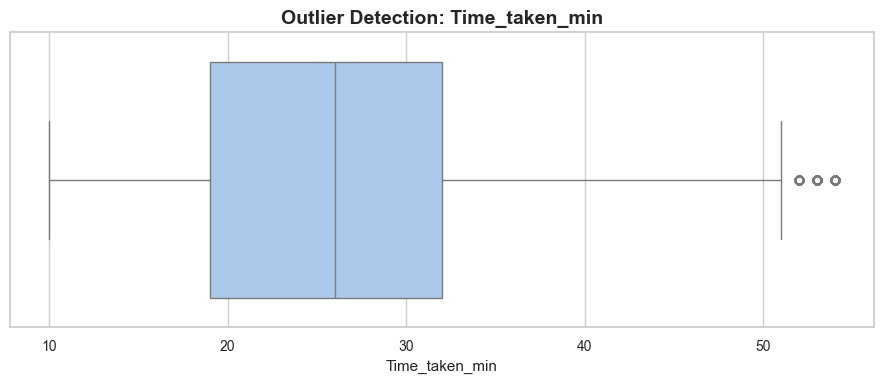

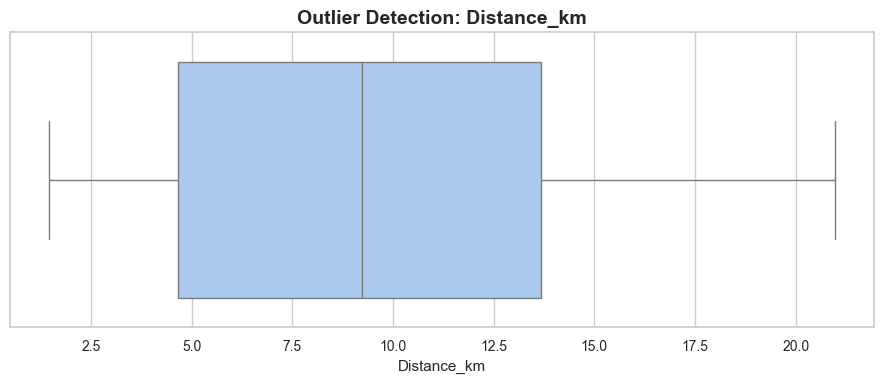

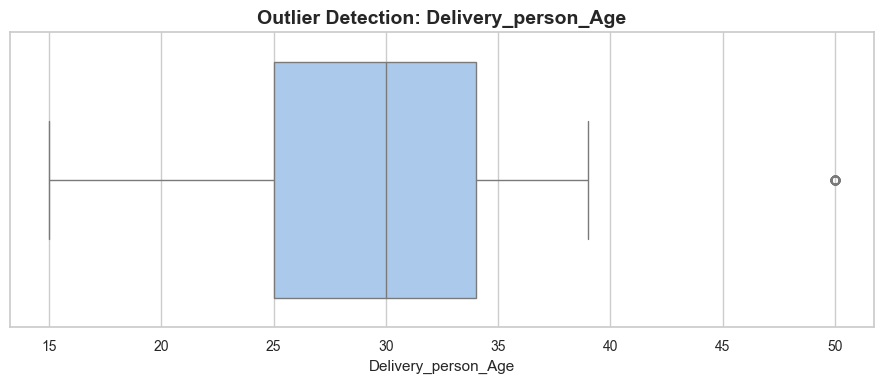

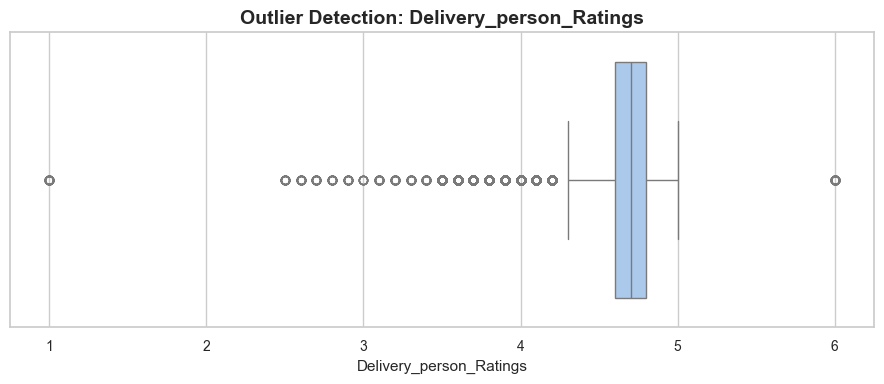

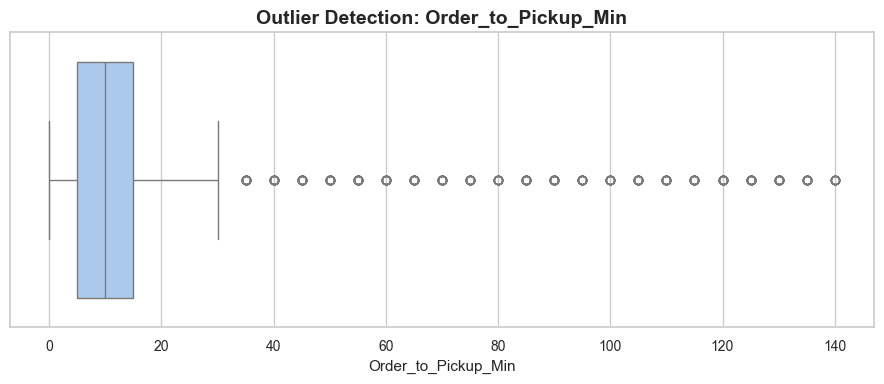

In [66]:
important_numeric = []
for col in ["Time_taken_min", "Distance_km", "Delivery_person_Age", "Delivery_person_Ratings", "Order_to_Pickup_Min"]:
    if col in df_clean.columns:
        important_numeric.append(col)

for col in important_numeric:
    plt.figure(figsize=(9, 4))
    sns.boxplot(data=df_clean, x=col)
    plt.title(f"Outlier Detection: {col}", weight="bold")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [67]:
def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = data[(data[col] < lower) | (data[col] > upper)]
        rows.append({
            "Column": col,
            "Lower_Bound": round(lower, 2),
            "Upper_Bound": round(upper, 2),
            "Outlier_Count": len(outliers),
            "Outlier_Percentage": round(len(outliers) / len(data) * 100, 2)
        })
    return pd.DataFrame(rows)

outlier_report = iqr_outlier_summary(df_clean, important_numeric)
display(outlier_report)

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Time_taken_min,-0.50,51.50,270,0.59
1,Distance_km,-8.86,27.21,0,0.00
2,Delivery_person_Age,11.50,47.50,53,0.12
3,Delivery_person_Ratings,4.30,5.10,5345,11.72
4,Order_to_Pickup_Min,-10.00,30.00,349,0.77


## 7. Exploratory Data Analysis

This section focuses on professional and interview-friendly insights.

### 7.1 Delivery Time Distribution

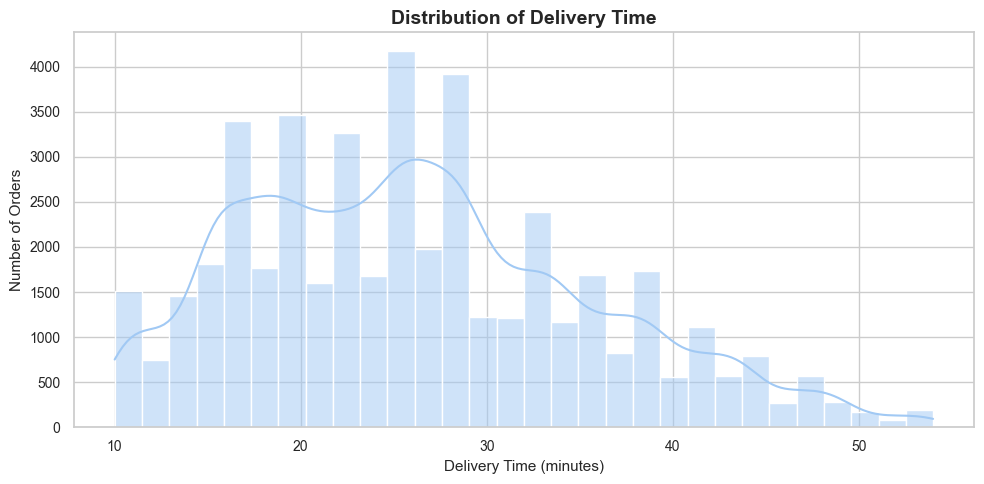

Average Delivery Time: 26.29 minutes
Median Delivery Time: 26.0 minutes


In [68]:
if "Time_taken_min" in df_clean.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_clean["Time_taken_min"], kde=True, bins=30)
    plt.title("Distribution of Delivery Time", weight="bold")
    plt.xlabel("Delivery Time (minutes)")
    plt.ylabel("Number of Orders")
    plt.tight_layout()
    plt.show()

    print("Average Delivery Time:", round(df_clean["Time_taken_min"].mean(), 2), "minutes")
    print("Median Delivery Time:", round(df_clean["Time_taken_min"].median(), 2), "minutes")

### 7.2 Delivery Time by Traffic Density

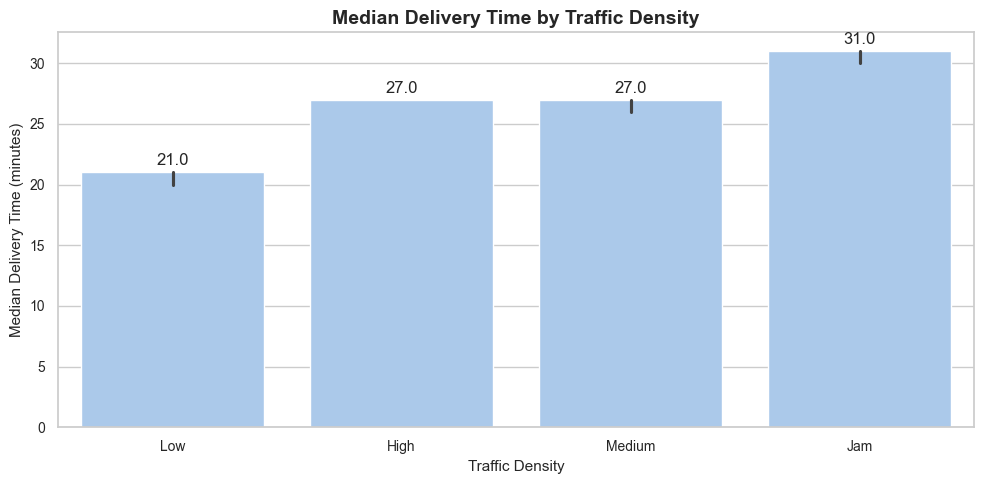

In [69]:
if "Road_traffic_density" in df_clean.columns and "Time_taken_min" in df_clean.columns:
    traffic_order = (
        df_clean.groupby("Road_traffic_density")["Time_taken_min"]
        .median()
        .sort_values()
        .index
    )

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=df_clean,
        x="Road_traffic_density",
        y="Time_taken_min",
        estimator=np.median,
        order=traffic_order
    )
    plt.title("Median Delivery Time by Traffic Density", weight="bold")
    plt.xlabel("Traffic Density")
    plt.ylabel("Median Delivery Time (minutes)")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)
    plt.tight_layout()
    plt.show()

### 7.3 Delivery Time by Weather Condition

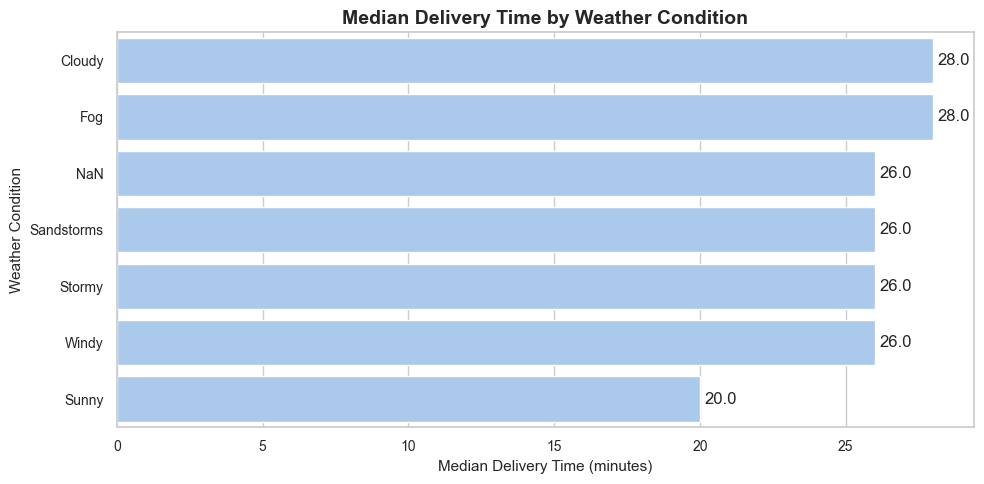

In [70]:
if "Weather_conditions" in df_clean.columns and "Time_taken_min" in df_clean.columns:
    weather_stats = (
        df_clean.groupby("Weather_conditions")["Time_taken_min"]
        .median()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=weather_stats, x="Time_taken_min", y="Weather_conditions")
    plt.title("Median Delivery Time by Weather Condition", weight="bold")
    plt.xlabel("Median Delivery Time (minutes)")
    plt.ylabel("Weather Condition")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)
    plt.tight_layout()
    plt.show()

### 7.4 Delivery Time by City Type

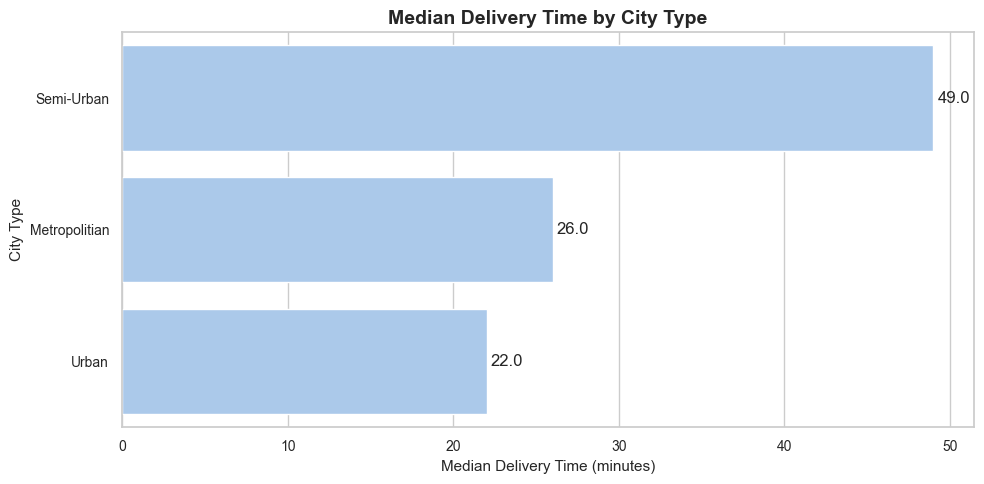

In [71]:
if "City" in df_clean.columns and "Time_taken_min" in df_clean.columns:
    city_stats = (
        df_clean.groupby("City")["Time_taken_min"]
        .median()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=city_stats, x="Time_taken_min", y="City")
    plt.title("Median Delivery Time by City Type", weight="bold")
    plt.xlabel("Median Delivery Time (minutes)")
    plt.ylabel("City Type")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)
    plt.tight_layout()
    plt.show()

### 7.5 Distance vs Delivery Time

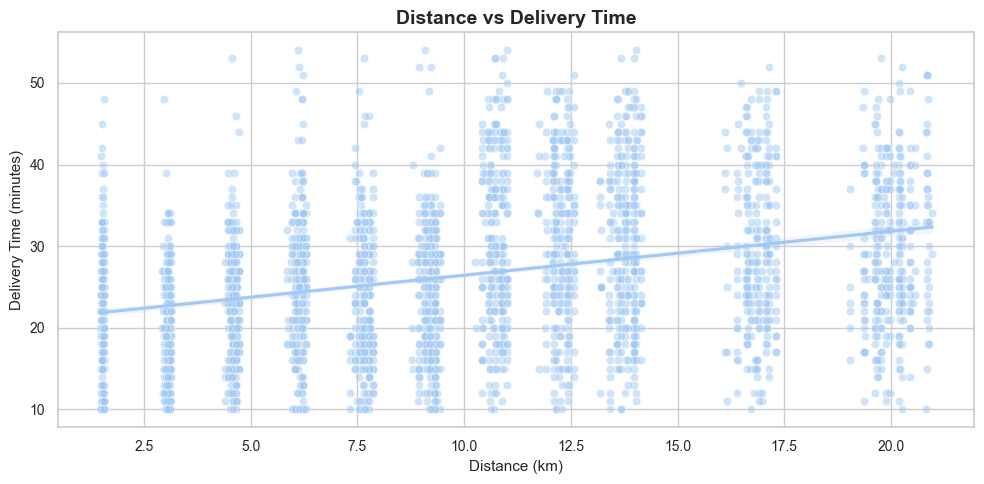

In [72]:
if "Distance_km" in df_clean.columns and "Time_taken_min" in df_clean.columns:
    sample_df = df_clean.sample(min(3000, len(df_clean)), random_state=42)

    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=sample_df, x="Distance_km", y="Time_taken_min", alpha=0.5)
    sns.regplot(data=sample_df, x="Distance_km", y="Time_taken_min", scatter=False)
    plt.title("Distance vs Delivery Time", weight="bold")
    plt.xlabel("Distance (km)")
    plt.ylabel("Delivery Time (minutes)")
    plt.tight_layout()
    plt.show()

### 7.6 Ratings vs Delivery Time

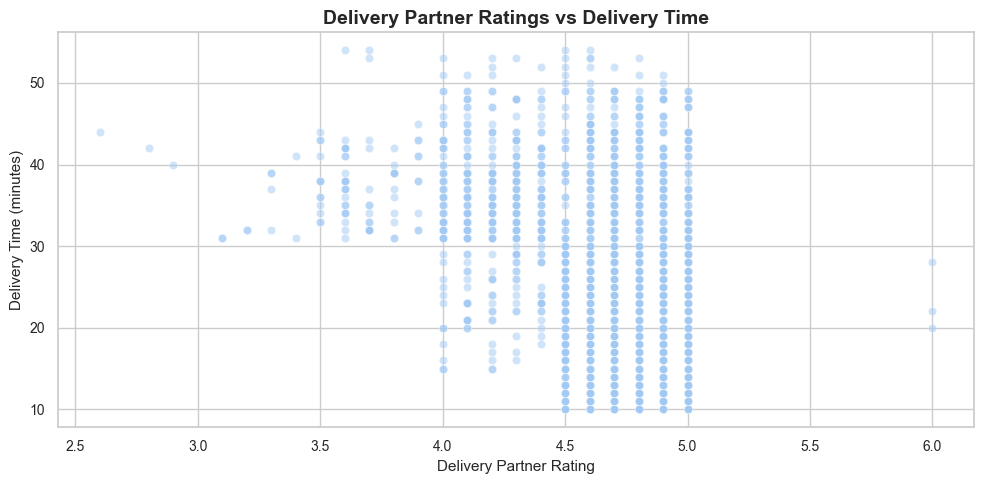

In [73]:
if "Delivery_person_Ratings" in df_clean.columns and "Time_taken_min" in df_clean.columns:
    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=df_clean.sample(min(3000, len(df_clean)), random_state=42),
        x="Delivery_person_Ratings",
        y="Time_taken_min",
        alpha=0.5
    )
    plt.title("Delivery Partner Ratings vs Delivery Time", weight="bold")
    plt.xlabel("Delivery Partner Rating")
    plt.ylabel("Delivery Time (minutes)")
    plt.tight_layout()
    plt.show()

### 7.7 Correlation Heatmap

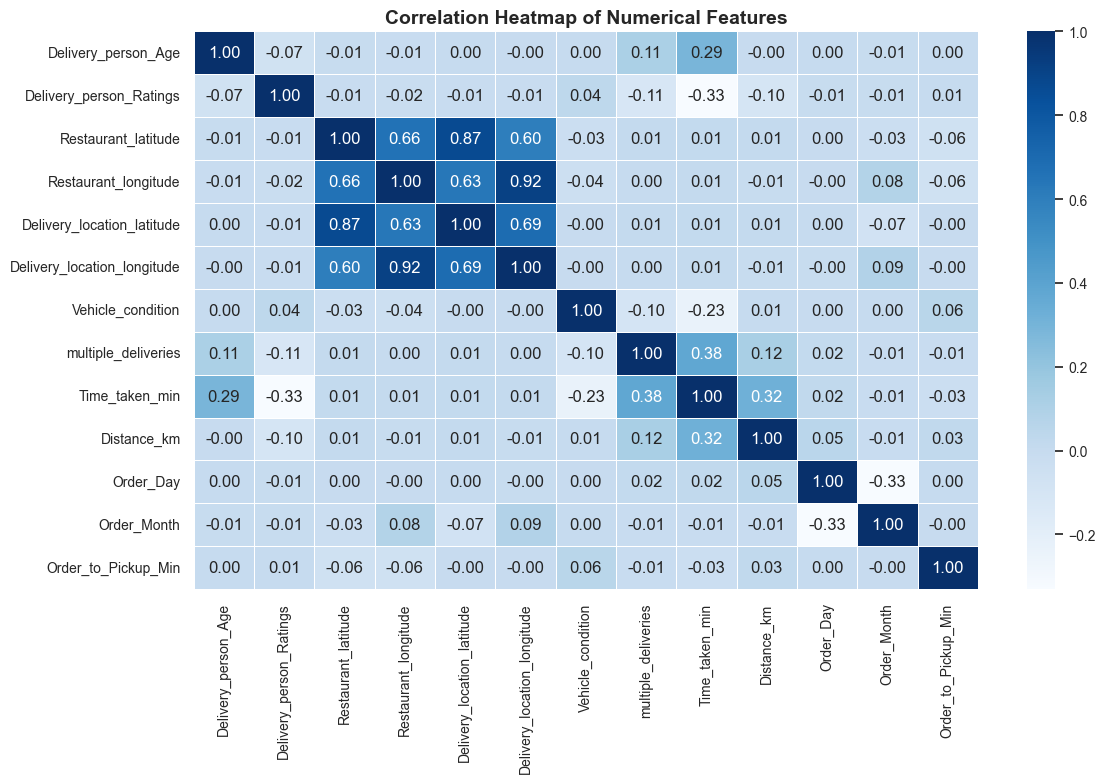

In [74]:
numeric_df = df_clean.select_dtypes(include=np.number)

if numeric_df.shape[1] > 1:
    plt.figure(figsize=(12, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
    plt.title("Correlation Heatmap of Numerical Features", weight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for correlation heatmap.")

## 8. Business Insights

These insights are automatically generated from the cleaned dataset.

In [75]:
insights = []

if "Time_taken_min" in df_clean.columns:
    avg_time = df_clean["Time_taken_min"].mean()
    insights.append(f"Average delivery time is approximately {avg_time:.2f} minutes.")

if "Road_traffic_density" in df_clean.columns and "Time_taken_min" in df_clean.columns:
    traffic_impact = (
        df_clean.groupby("Road_traffic_density")["Time_taken_min"]
        .median()
        .sort_values(ascending=False)
    )
    insights.append(
        f"Highest median delivery time is observed during '{traffic_impact.index[0]}' traffic "
        f"with around {traffic_impact.iloc[0]:.2f} minutes."
    )

if "Weather_conditions" in df_clean.columns and "Time_taken_min" in df_clean.columns:
    weather_impact = (
        df_clean.groupby("Weather_conditions")["Time_taken_min"]
        .median()
        .sort_values(ascending=False)
    )
    insights.append(
        f"Weather condition '{weather_impact.index[0]}' has the highest median delivery time "
        f"of around {weather_impact.iloc[0]:.2f} minutes."
    )

if "Distance_km" in df_clean.columns and "Time_taken_min" in df_clean.columns:
    distance_corr = df_clean[["Distance_km", "Time_taken_min"]].corr().iloc[0, 1]
    insights.append(
        f"Distance and delivery time have a correlation of {distance_corr:.2f}, "
        "showing how strongly distance affects delivery duration."
    )

if "City" in df_clean.columns and "Time_taken_min" in df_clean.columns:
    city_impact = (
        df_clean.groupby("City")["Time_taken_min"]
        .median()
        .sort_values(ascending=False)
    )
    insights.append(
        f"City type '{city_impact.index[0]}' shows the highest median delivery time "
        f"with around {city_impact.iloc[0]:.2f} minutes."
    )

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. Average delivery time is approximately 26.29 minutes.
2. Highest median delivery time is observed during 'Jam' traffic with around 31.00 minutes.
3. Weather condition 'Cloudy' has the highest median delivery time of around 28.00 minutes.
4. Distance and delivery time have a correlation of 0.32, showing how strongly distance affects delivery duration.
5. City type 'Semi-Urban' shows the highest median delivery time with around 49.00 minutes.


## 9. Small Machine Learning Prediction

Main focus of this project is Data Science and insights.  
But this section shows basic prediction knowledge using regression models.

### Target
Predict `Time_taken_min`.

In [76]:
model_df = df_clean.copy()

if "Time_taken_min" not in model_df.columns:
    raise ValueError("Target column Time_taken_min not found.")

# Drop columns that are IDs or too raw/unnecessary for beginner model
drop_candidates = [
    "ID", "Delivery_person_ID", "Order_Date", 
    "Time_Ordered", "Time_Order_picked"
]

available_drop_cols = [col for col in drop_candidates if col in model_df.columns]

ml_data = model_df.drop(columns=available_drop_cols, errors="ignore").copy()

# Separate features and target
X = ml_data.drop(columns=["Time_taken_min"])
y = ml_data["Time_taken_min"]

# Identify column types
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)
print("Target: Time_taken_min")

Numeric Features: ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries', 'Distance_km', 'Order_Day', 'Order_Month', 'Order_to_Pickup_Min']
Categorical Features: ['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'Order_Weekday']
Target: Time_taken_min


In [77]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        random_state=42,
        max_depth=12,
        n_jobs=-1
    )
}

results = []

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2_Score": round(r2, 3)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="R2_Score", ascending=False)
display(results_df)

,Model,MAE,RMSE,R2_Score
1,Random Forest,3.17,3.96,0.821
0,Linear Regression,4.78,6.01,0.588


### Model Performance Visualization

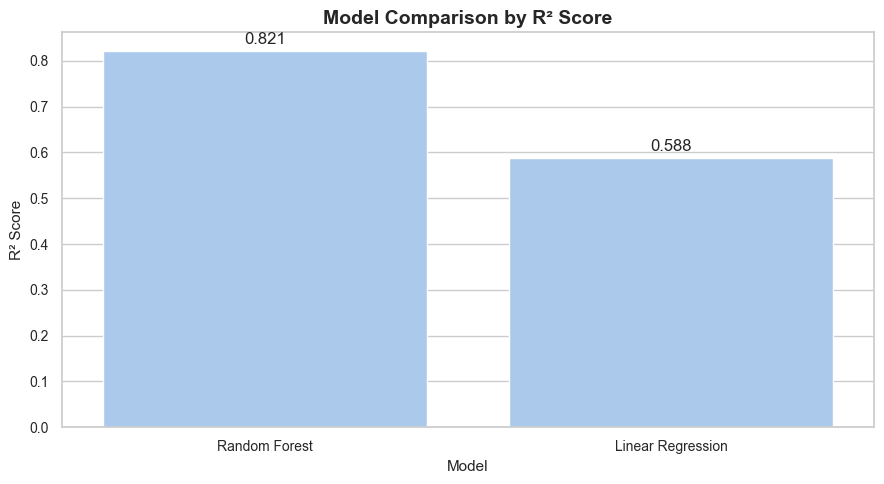

In [78]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=results_df, x="Model", y="R2_Score")
plt.title("Model Comparison by R² Score", weight="bold")
plt.xlabel("Model")
plt.ylabel("R² Score")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

### Actual vs Predicted Delivery Time

,Actual_Time_Min,Predicted_Time_Min
0,44.0,41.95
1,41.0,44.92
2,39.0,37.05
3,38.0,41.32
4,38.0,42.44
5,22.0,23.21
6,14.0,15.30
7,17.0,22.47
8,22.0,21.41
9,29.0,25.25


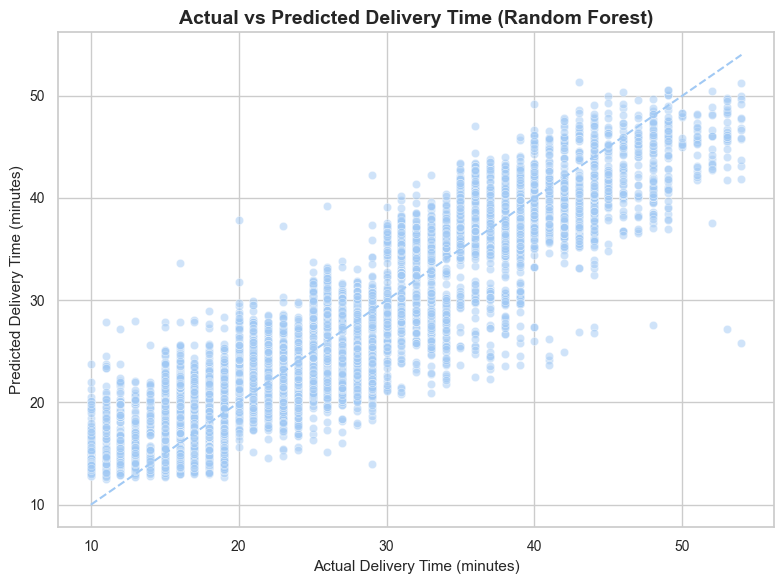

In [79]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual_Time_Min": y_test.values,
    "Predicted_Time_Min": np.round(y_pred_best, 2)
})

display(comparison_df.head(10))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=comparison_df["Actual_Time_Min"], y=comparison_df["Predicted_Time_Min"], alpha=0.5)
plt.plot(
    [comparison_df["Actual_Time_Min"].min(), comparison_df["Actual_Time_Min"].max()],
    [comparison_df["Actual_Time_Min"].min(), comparison_df["Actual_Time_Min"].max()],
    linestyle="--"
)
plt.title(f"Actual vs Predicted Delivery Time ({best_model_name})", weight="bold")
plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.tight_layout()
plt.show()

### Predict One or Two New Records

This is useful for interview demonstration.

In [80]:
# Take 2 real examples from test data and predict them
sample_orders = X_test.head(2).copy()
sample_predictions = best_model.predict(sample_orders)

sample_output = sample_orders.copy()
sample_output["Predicted_Delivery_Time_Min"] = np.round(sample_predictions, 2)

display(sample_output)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Distance_km,Order_Day,Order_Month,Order_Weekday,Order_to_Pickup_Min,Predicted_Delivery_Time_Min
7725,30.0,5.0,22.744648,75.894377,22.824648,75.974377,Fog,Medium,0,Snack,motorcycle,0.0,Yes,Metropolitian,12.099391,20,3,Sunday,15.0,41.95
949,31.0,4.7,21.173343,72.792731,21.263343,72.882731,Fog,Jam,2,Drinks,motorcycle,2.0,No,Metropolitian,13.681492,31,3,Thursday,5.0,44.92


## 10. Final Conclusion

### Project Summary
This project analyzed food delivery operations using a real Kaggle dataset.  
The main objective was to understand what factors influence delivery time and to build a beginner-friendly prediction model.

### Key Findings
- Traffic density and weather conditions have visible impact on delivery time.
- Distance is an important feature for estimating delivery duration.
- City type and delivery partner-related features can also affect delivery performance.
- Outliers are present in delivery time and distance, which is expected in real logistics data.

### Machine Learning Result
A simple regression model was created to predict delivery time in minutes.  
This shows basic ML knowledge while keeping the project mainly focused on Data Science and business insights.

### Business Recommendations
- Improve delivery planning during high traffic periods.
- Assign experienced delivery partners during bad weather or long-distance orders.
- Use prediction models to show more realistic estimated delivery time to customers.
- Monitor city-wise delivery performance to identify operational bottlenecks.